In [23]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib as mp
import matplotlib.pyplot as plt

In [24]:
method_rename_dict = {
        'velocyto': "Velocyto",
        'scvelo_dyn': "scVelo (dyn)",
        'scvelo_stc': "scVelo (stc)",
        'veloae': "VeloAE",
        'dynamo_m1': "Dynamo (m1)",
        'unitvelo_ind': "UniTVelo (ind)",
        'unitvelo_uni': "UniTVelo (uni)",
        'velovae_std': "VeloVAE (std)",
        'velovae_fullvb': "VeloVAE (Full VB)",
        'deepvelo': "DeepVelo",
        'celldancer': "cellDancer",
        'pyrovelocity_m1': "Pyro-Velocity (m1)",
        'pyrovelocity_m2': "Pyro-Velocity (m2)",
        'kvelo': "  -velo",
        'velovi': "veloVI",
        'cell2fate': "cell2fate",
        'sdevelo': "SDEvelo",
        'svelvetvae': "SvelvetVAE",
        'latentvelo_std': "LatentVelo (std)",
        'tivelo_std': "TIVelo (std)",
        'tivelo_simple': "TIVelo (simple)",
        'sctour_mse': "scTour (MSE)",
        'sctour_nb': "scTour (NB)",
        'sctour_zinb': "scTour (ZINB)",
        'velvetvae': "VelvetVAE",
        'graphvelo_std': "GraphVelo (std)"
}

dataset_rename_dict = {
    'data01': "Data 1",
    'data02': "Data 2",
    'data03': "Data 3",
    'data04': "Data 4",
    'data05': "Data 5",
    'data06': "Data 6",
    'data07': "Data 7",
    'data08': "Data 8",
    'data09': "Data 9",
    'data10': "Data 10"

}


In [25]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import matplotlib.lines as mlines


def plot_method_dataset_bubble(
    concat_df: pd.DataFrame,
    method_col: str = "Method",
    dataset_col: str = "dataset",
    value_col: str = "dataset_mean",   # Value for bar length & color (mean)
    size_col: str = "dataset_std",     # Standard deviation used for error bars
    method_order: List[str] = None,    # ✅ Required: Specify method order (top to bottom)
    dataset_order: List[str] = None,   # ✅ Required: Specify dataset order (left to right)
    cmap: str = "viridis",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    size_min: float = 50,              # ✅ Kept for compatibility (not used in this implementation)
    size_max: float = 1200,            # ✅ Kept for compatibility (not used in this implementation)
    annotate: bool = False,
    ann_fmt: str = "{:.2f}",
    figsize: Optional[Tuple[float, float]] = None,
    title: Optional[str] = None,
    size_transform: str = "sqrt",      # ✅ Kept for compatibility (not used in this implementation)
    size_clip: Tuple[float, float] = (0.05, 0.95),  # ✅ Kept for compatibility (not used in this implementation)
    row_stripes: bool = True,
    stripe_light: float = 0.95,
    stripe_contrast: float = 0.08,
    column_spacing: float = 1.0,       # ✅ Kept for compatibility (not used in this implementation)
    trim_to_span: bool = True,         # ✅ Kept for compatibility (not used in this implementation)
    return_span: bool = False,         # ✅ Kept for compatibility (returns a placeholder span)
    size_domain: Optional[Tuple[float, float]] = None,  # ✅ Kept for compatibility (not used in this implementation)
    size_ref_values: Optional[np.ndarray] = None,       # ✅ Kept for compatibility (not used in this implementation)
    size_reverse: bool = True,         # ✅ Kept for compatibility (not used in this implementation)
    colors: List[str] = None,
    bar_outline: bool = True,
):
    # === Parameter Check ===
    if not method_order or not isinstance(method_order, list):
        raise ValueError("method_order must be a non-empty List[str] to explicitly specify the row order of methods.")
    if not dataset_order or not isinstance(dataset_order, list):
        raise ValueError("dataset_order must be a non-empty List[str] to explicitly specify the column order of datasets.")

    df = concat_df.copy()
    df = df[df[method_col].isin(method_order) & df[dataset_col].isin(dataset_order)].copy()
    if df.empty:
        raise ValueError("No data available for plotting after filtering. Please check if method_order and dataset_order match.")

    # === Color Mapping ===
    vals_all = df[value_col].astype(float).values
    vmin = np.nanmin(vals_all) if vmin is None else vmin
    vmax = np.nanmax(vals_all) if vmax is None else vmax
    if not np.isfinite(vmin):
        vmin = 0.0
    if not np.isfinite(vmax):
        vmax = vmin + 1.0
    if vmin == vmax:
        vmax = vmin + 1e-9

    colors = colors
    cmap_obj = LinearSegmentedColormap.from_list("custom", colors, N=256)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    # === Organize into Matrix and Align by Order ===
    methods = list(method_order)
    datasets = list(dataset_order)

    # Independent x-axis range for each column (dataset)
    xlims = {}
    for d in datasets:
        sub = df[df[dataset_col] == d]
        means = sub[value_col].astype(float).to_numpy()
        stds = sub[size_col].astype(float).to_numpy()
        stds = np.where(np.isnan(stds), 0.0, stds)
        if means.size == 0:
            lo, hi = 0.0, 1.0
        else:
            lo = np.nanmin(means - stds)
            hi = np.nanmax(means + stds)
        if not np.isfinite(lo):
            lo = 0.0
        if not np.isfinite(hi):
            hi = 1.0
        if np.isclose(lo, hi):
            lo -= 0.1
            hi += 0.1
        pad = (hi - lo) * 0.05
        xlims[d] = (lo - pad, hi + pad)

    # === Figure and Grid ===
    n_rows = len(methods)
    n_cols = len(datasets)
    n_cols_gs = n_cols + 1   # ✅ Add one extra column as a blank placeholder (Column 0)

    if figsize is None:
        fig_w = max(6.5, n_cols_gs * 1 + 2.0)  # ✅ Width calculated based on total number of columns
        fig_h = max(4.5, n_rows * 0.45 + 1.5)
        figsize = (fig_w, fig_h)

    plt.rcParams['axes.facecolor'] = 'none'
    fig = plt.figure(figsize=figsize, dpi=300)
    width_ratios = [2.5] + [1.5] * n_cols
    gs = GridSpec(n_rows, n_cols_gs, figure=fig, wspace=0.05, hspace=0.05,width_ratios=width_ratios)

    # === Row Stripe Background (Automatically extends to method name column + blank column) ===
    if row_stripes:
        light_v = max(0.0, min(1.0, stripe_light))
        dark_v = max(0.0, min(1.0, light_v - stripe_contrast))
        row_bg_light = (light_v, light_v, light_v)
        row_bg_dark = (dark_v, dark_v, dark_v)

        # ✅ The first barplot column is now at gs[:, 1]; use it to estimate label area width
        bbox_first = gs[0, 1].get_position(fig)
        label_width = bbox_first.width * 1.5
        x_left = bbox_first.x0 - label_width  # Leftmost position of method names
        x_left -= 0.1

        for i in range(n_rows):
            bbox = gs[i, :].get_position(fig)  # ✅ Includes blank column + all data columns
            band_color = row_bg_light if (i % 2 == 0) else row_bg_dark
            fig.patches.append(
                Rectangle(
                    (x_left, bbox.y0),
                    bbox.x1 - x_left,  # ✅ Covers: method name column + blank column + all bar columns
                    bbox.height,
                    transform=fig.transFigure,
                    color=band_color,
                    zorder=-50,
                    lw=0,
                )
            )
            if i < n_rows - 1:
                next_bbox = gs[i + 1, :].get_position(fig)
                y_line = (bbox.y0 + next_bbox.y1) / 2
                fig.lines.append(
                    mlines.Line2D(
                        [x_left, bbox.x1],
                        [y_line, y_line],
                        transform=fig.transFigure,
                        color="#e6e6e6",
                        linewidth=1.2,
                        zorder=-40,
                    )
                )

        # Outer frame (includes method names + blank column + all bar columns)
        top_bbox = gs[0, :].get_position(fig)
        bottom_bbox = gs[n_rows - 1, :].get_position(fig)
        fig.lines.append(
            mlines.Line2D(
                [x_left, top_bbox.x1],
                [top_bbox.y1, top_bbox.y1],
                transform=fig.transFigure,
                color="#e6e6e6",
                linewidth=1.2,
                zorder=-30,
            )
        )
        fig.lines.append(
            mlines.Line2D(
                [x_left, bottom_bbox.x1],
                [bottom_bbox.y0, bottom_bbox.y0],
                transform=fig.transFigure,
                color="#e6e6e6",
                linewidth=1.2,
                zorder=-30,
            )
        )
        fig.lines.append(
            mlines.Line2D(
                [x_left, x_left],
                [bottom_bbox.y0, top_bbox.y1],
                transform=fig.transFigure,
                color="#e6e6e6",
                linewidth=1.2,
                zorder=-30,
            )
        )
        fig.lines.append(
            mlines.Line2D(
                [top_bbox.x1, top_bbox.x1],
                [bottom_bbox.y0, top_bbox.y1],
                transform=fig.transFigure,
                color="#e6e6e6",
                linewidth=1.2,
                zorder=-30,
            )
        )

    # === Plot Bars + Error Bars Cell by Cell ===
    axs = np.empty((n_rows, n_cols), dtype=object)  # ✅ What is returned to the user is still n_cols (excluding the blank column)

    for i, m in enumerate(methods):
        for j, d in enumerate(datasets):
            # ✅ The actual barplot is placed in column j+1; column 0 is left blank
            ax = fig.add_subplot(gs[i, j + 1])
            ax.set_facecolor("none")
            axs[i, j] = ax

            sub = df[(df[method_col] == m) & (df[dataset_col] == d)]
            if sub.empty:
                ax.axis("off")
                continue

            mean = float(sub[value_col].iloc[0])
            std = float(sub[size_col].iloc[0]) if pd.notna(sub[size_col].iloc[0]) else np.nan
            color = cmap_obj(norm(mean))

            if bar_outline:
                edgecolor = "black"
                linewidth = 0.3
            else:
                edgecolor = "none"
                linewidth = 0.0

            ax.barh(
                [0],
                [mean],
                height=1.0,
                color=color,
                alpha=1.0,
                edgecolor=edgecolor,
                linewidth=linewidth,
            )

            if np.isfinite(std):
                ax.errorbar(
                    [mean],
                    [0],
                    xerr=[[std], [std]],
                    fmt="none",
                    ecolor="black",
                    elinewidth=0.8,
                    capsize=2.5,
                )

            lo, hi = xlims[d]
            ax.set_xlim(lo, hi)
            ax.set_ylim(-0.8, 0.8)
            ax.set_xticks([])
            ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_visible(False)

            if annotate and np.isfinite(mean):
                ha = "left" if mean < 0 else "right"
                offset = (hi - lo) * 0.01
                x_txt = mean - offset if mean > 0 else mean + offset
                ax.text(
                    x_txt,
                    0,
                    ann_fmt.format(mean),
                    ha=ha,
                    va="center",
                    fontsize=8,
                    color="black",
                )

    # === Method Names on the Left (Still based on the position of the first barplot column) ===
    for i, m in enumerate(methods):
        left_ax = axs[i, 0]
        if left_ax is not None:
            bbox = left_ax.get_position()
            fig.text(
                bbox.x0 - 0.12,          # Still leave some spacing for the "Method Name Column"
                (bbox.y0 + bbox.y1) / 2,
                str(m),
                ha="center",
                va="center",
                fontsize=8,
            )

    if title:
        fig.suptitle(
            title,
            y=0.995,
            fontsize=10,
        )

    if return_span:
        span = (0.0, float(n_cols))
        return fig, axs, span

    return fig, axs

## Aggregate scores

In [26]:
datasets = ['data01', 
            'data02', 
            'data03', 
            'data04', 
            'data05',
            'data06',
            'data07',
            'data08',
            'data09',
            'data10']

metric_name = 'cbdir'

In [27]:
all_scores = []
for dataset in datasets:
    df = pd.read_csv( Path(dataset) / f"{metric_name}_df.csv")
    if metric_name == 'cbdir':
        df.iloc[:, 1:] = (df.iloc[:, 1:] + 1) / 2 
    df_mean_std = df.copy()
    df_mean_std["dataset_mean"] = df_mean_std.iloc[:, 1:].mean(axis=1)
    df_mean_std["dataset_std"] = df_mean_std.iloc[:, 1:].std(axis=1)
    df_mean_std = df_mean_std[["Method", "dataset_mean", "dataset_std"]]
    df_mean_std["dataset"] = dataset
    all_scores.append(df_mean_std)
concat_df = pd.concat(all_scores, ignore_index=True)
concat_df["Method"] = concat_df["Method"].map(method_rename_dict)
concat_df["dataset"] = concat_df["dataset"].map(dataset_rename_dict)
overall_mean = (
    concat_df.groupby("Method")["dataset_mean"]
    .mean()
    .reset_index()
    .rename(columns={"dataset_mean": "overall_mean"})
)
overall_mean['rank'] = overall_mean['overall_mean'].rank(ascending=False)

method_order = (
    overall_mean.sort_values(by="overall_mean", ascending=False)["Method"]
    .tolist()
)

In [28]:
import pandas as pd

df_all = pd.concat(
    [
        df.assign(dataset=name)
        for df, name in zip(all_scores, datasets)
    ],
    ignore_index=True
)

method_mean = (
    df_all
    .groupby("Method", as_index=False)["dataset_mean"]
    .mean()
    .rename(columns={"dataset_mean": "mean_dataset_mean"})
)

method_mean["Method"] = (
    method_mean["Method"]
    .map(method_rename_dict)
    .fillna(method_mean["Method"])
)

method_mean["rank"] = (
    method_mean["mean_dataset_mean"]
    .rank(ascending=False, method="min")
    .astype(int)
)

method_mean = method_mean.sort_values("rank")

print(method_mean)

method_mean.to_csv(f'cbdir_ranking.csv', index=False)


                Method  mean_dataset_mean  rank
18      UniTVelo (ind)           0.626051     1
15          SvelvetVAE           0.598631     2
24              veloVI           0.597842     3
6     LatentVelo (std)           0.596198     4
21            Velocyto           0.584910     5
19      UniTVelo (uni)           0.584782     6
13        scVelo (stc)           0.579864     7
1           cellDancer           0.575646     8
17        TIVelo (std)           0.574698     9
16     TIVelo (simple)           0.558938    10
20              VeloAE           0.552923    11
8   Pyro-Velocity (m2)           0.545709    12
9         scTour (MSE)           0.544860    13
4      GraphVelo (std)           0.539373    14
2             DeepVelo           0.525916    15
10         scTour (NB)           0.522128    16
7   Pyro-Velocity (m1)           0.519415    17
11       scTour (ZINB)           0.518857    18
12        scVelo (dyn)           0.513822    19
14             SDEvelo           0.51325

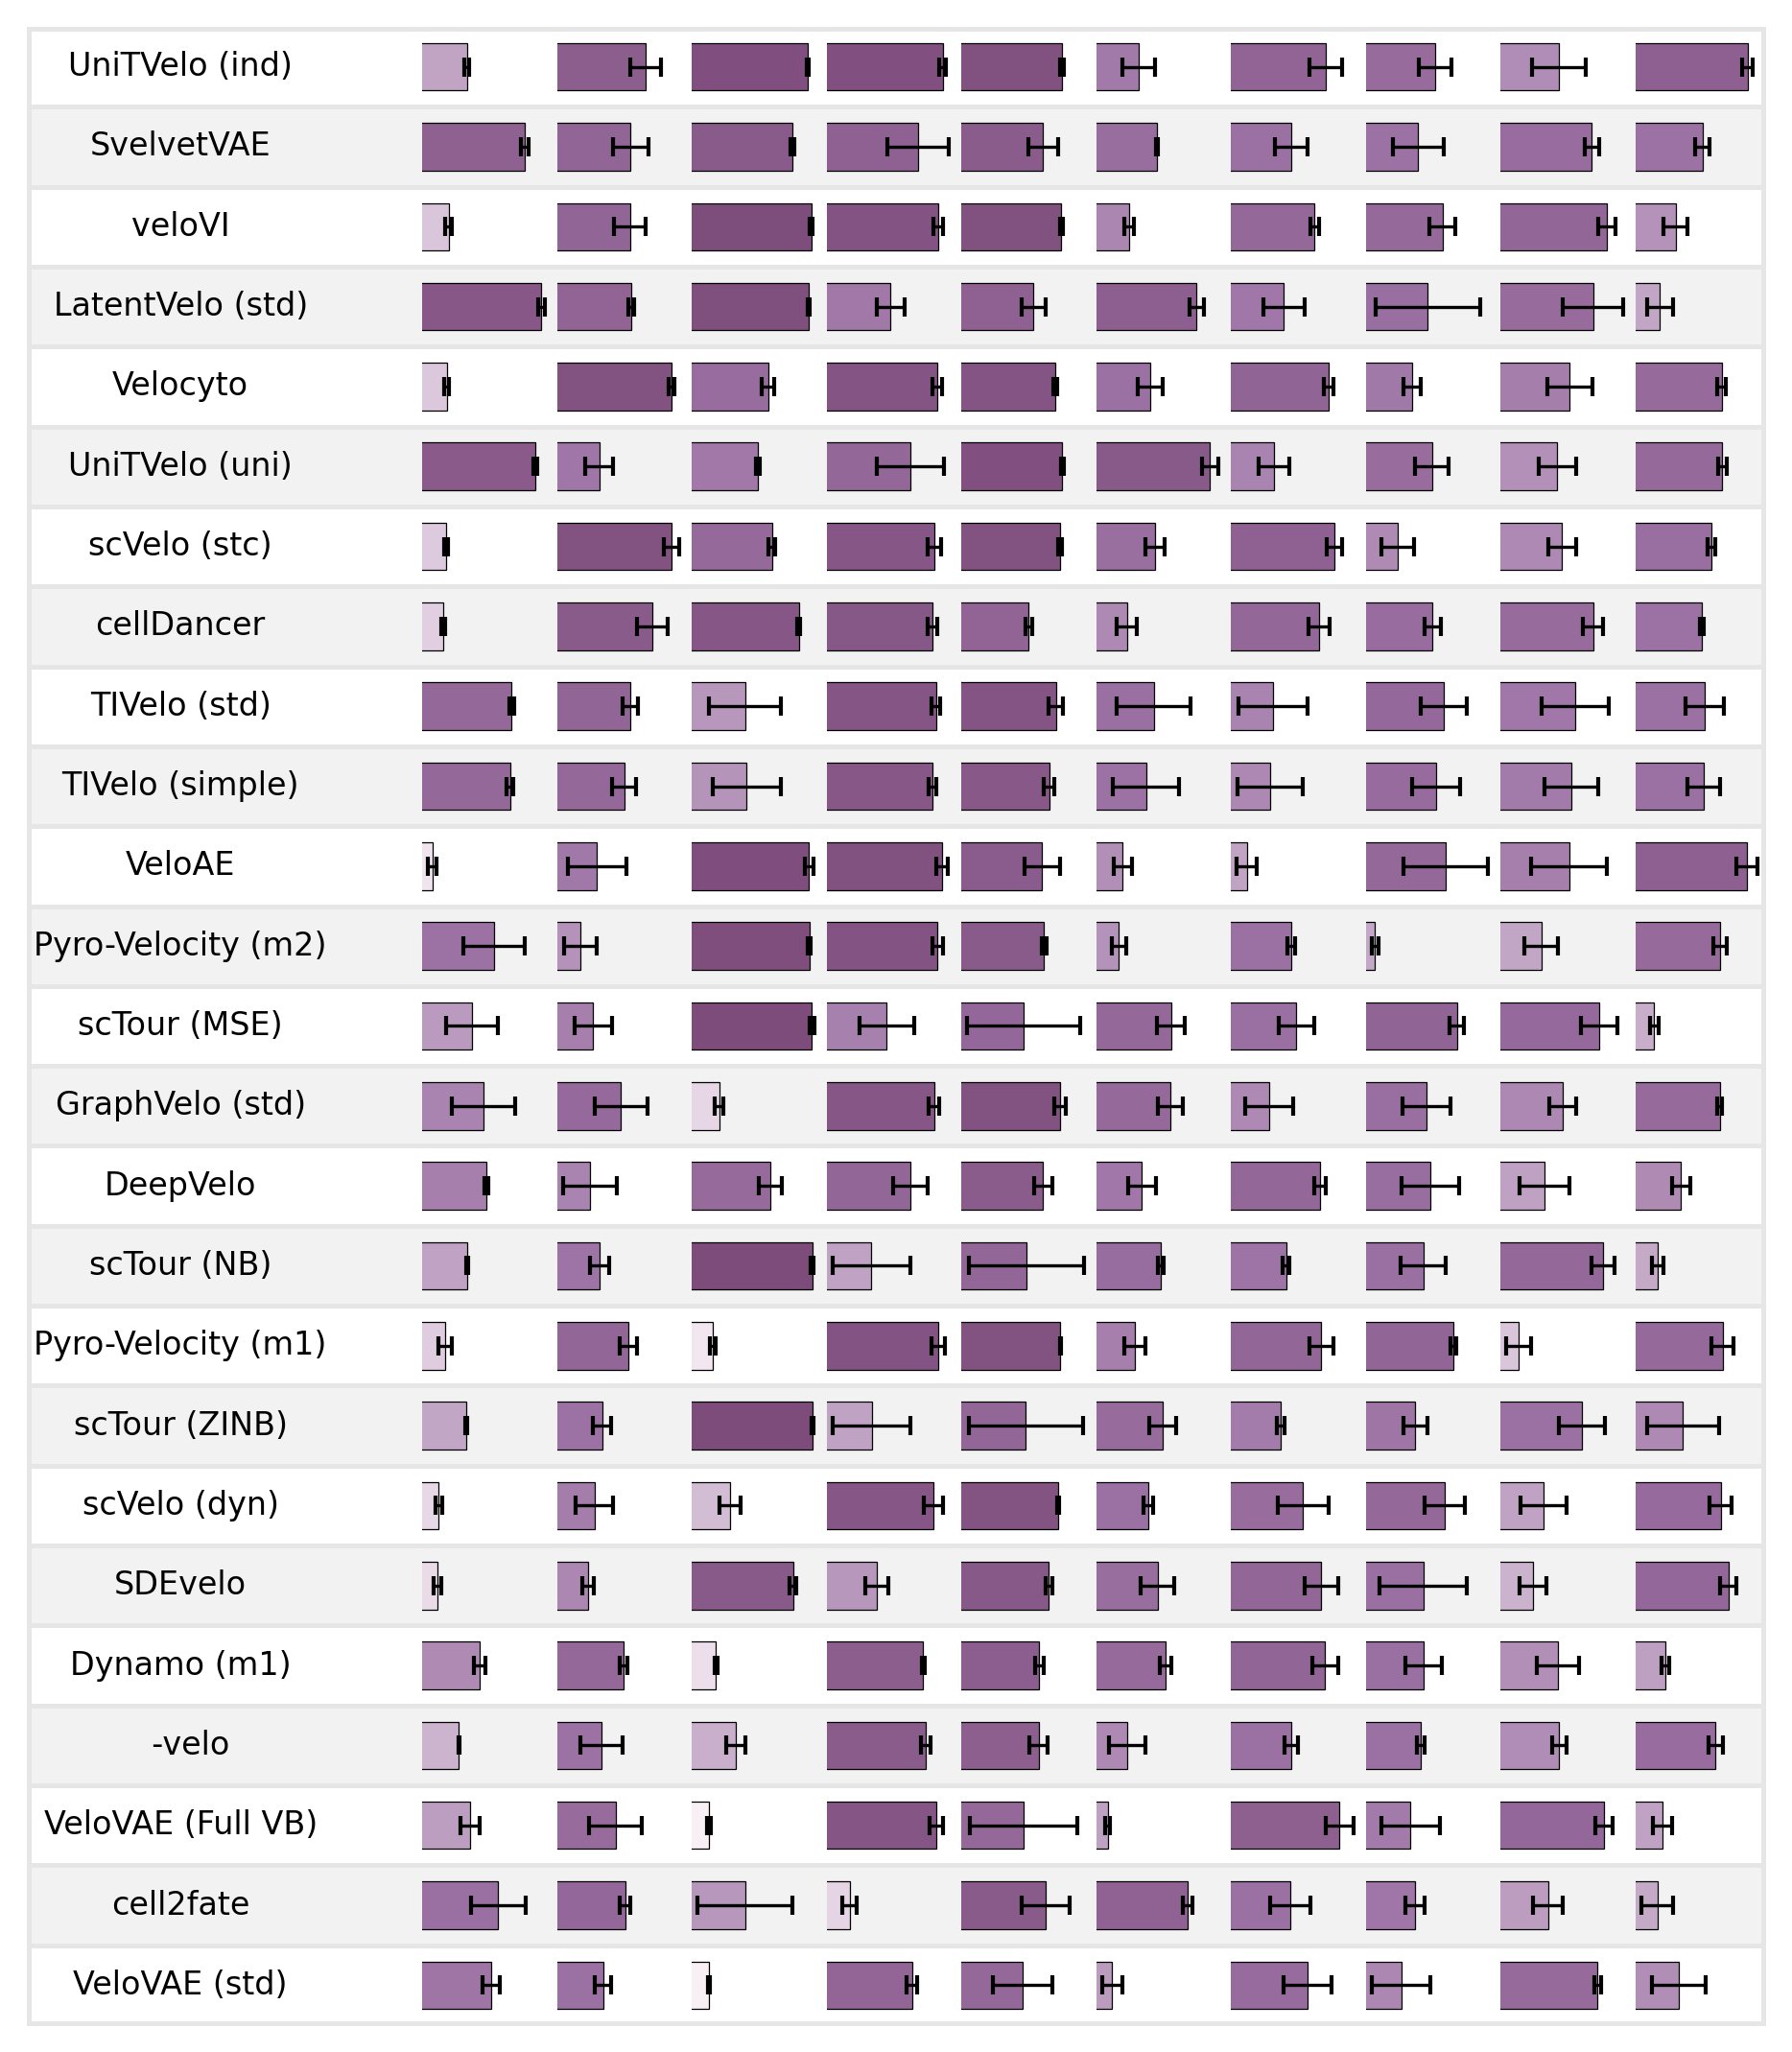

In [29]:
colors = ["#f9f0f6", "#9c72a4", "#7d4c7b"]
fig, ax = plot_method_dataset_bubble(
    concat_df,
    method_order=method_order,
    dataset_order = ['Data 1', 'Data 2', 'Data 3', 'Data 4', 'Data 5', 'Data 6', 'Data 7', 'Data 8', 'Data 9', 'Data 10'],
    figsize=(7, 9),
    size_transform="sqrt",
    size_clip=(0.05, 0.95),
    size_min=30, size_max=300,
    row_stripes=True,
    stripe_light=1,
    stripe_contrast=0.05,
    column_spacing=1,
    size_domain=(0.0, 0.65),
    colors=colors,
    bar_outline=True,
)
plt.tight_layout()
plt.savefig("cbdir_barplot.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()

In [30]:
metric_name = 'icvcoh'
all_scores = []
for dataset in datasets:
    df = pd.read_csv(Path(dataset) / f"{metric_name}_df.csv")
    if metric_name == 'cbdir':
        df.iloc[:, 1:] = (df.iloc[:, 1:] + 1) / 2 
    df_mean_std = df.copy()
    df_mean_std["dataset_mean"] = df_mean_std.iloc[:, 1:].mean(axis=1)
    df_mean_std["dataset_std"] = df_mean_std.iloc[:, 1:].std(axis=1)
    df_mean_std = df_mean_std[["Method", "dataset_mean", "dataset_std"]]
    df_mean_std["dataset"] = dataset
    all_scores.append(df_mean_std)
concat_df = pd.concat(all_scores, ignore_index=True)
concat_df["Method"] = concat_df["Method"].map(method_rename_dict)
concat_df["dataset"] = concat_df["dataset"].map(dataset_rename_dict)
overall_mean = (
    concat_df.groupby("Method")["dataset_mean"]
    .mean()
    .reset_index()
    .rename(columns={"dataset_mean": "overall_mean"})
)
overall_mean['rank'] = overall_mean['overall_mean'].rank(ascending=False)

method_order = (
    overall_mean.sort_values(by="overall_mean", ascending=False)["Method"]
    .tolist()
)

In [31]:
import pandas as pd

df_all = pd.concat(
    [
        df.assign(dataset=name)
        for df, name in zip(all_scores, datasets)
    ],
    ignore_index=True
)

method_mean = (
    df_all
    .groupby("Method", as_index=False)["dataset_mean"]
    .mean()
    .rename(columns={"dataset_mean": "mean_dataset_mean"})
)
method_mean["Method"] = (
    method_mean["Method"]
    .map(method_rename_dict)
    .fillna(method_mean["Method"])
)

method_mean["rank"] = (
    method_mean["mean_dataset_mean"]
    .rank(ascending=False, method="min")
    .astype(int)
)

method_mean = method_mean.sort_values("rank")

print(method_mean)

method_mean.to_csv(f'icvcoh_ranking.csv', index=False)

                Method  mean_dataset_mean  rank
6     LatentVelo (std)           0.880522     1
11       scTour (ZINB)           0.862733     2
19      UniTVelo (uni)           0.860433     3
10         scTour (NB)           0.835672     4
22   VeloVAE (Full VB)           0.833402     5
8   Pyro-Velocity (m2)           0.821310     6
20              VeloAE           0.820469     7
24              veloVI           0.807767     8
7   Pyro-Velocity (m1)           0.788262     9
18      UniTVelo (ind)           0.780499    10
2             DeepVelo           0.773980    11
9         scTour (MSE)           0.773101    12
14             SDEvelo           0.764552    13
12        scVelo (dyn)           0.740321    14
23       VeloVAE (std)           0.736923    15
17        TIVelo (std)           0.732165    16
0            cell2fate           0.729559    17
15          SvelvetVAE           0.703306    18
3          Dynamo (m1)           0.702400    19
13        scVelo (stc)           0.66722

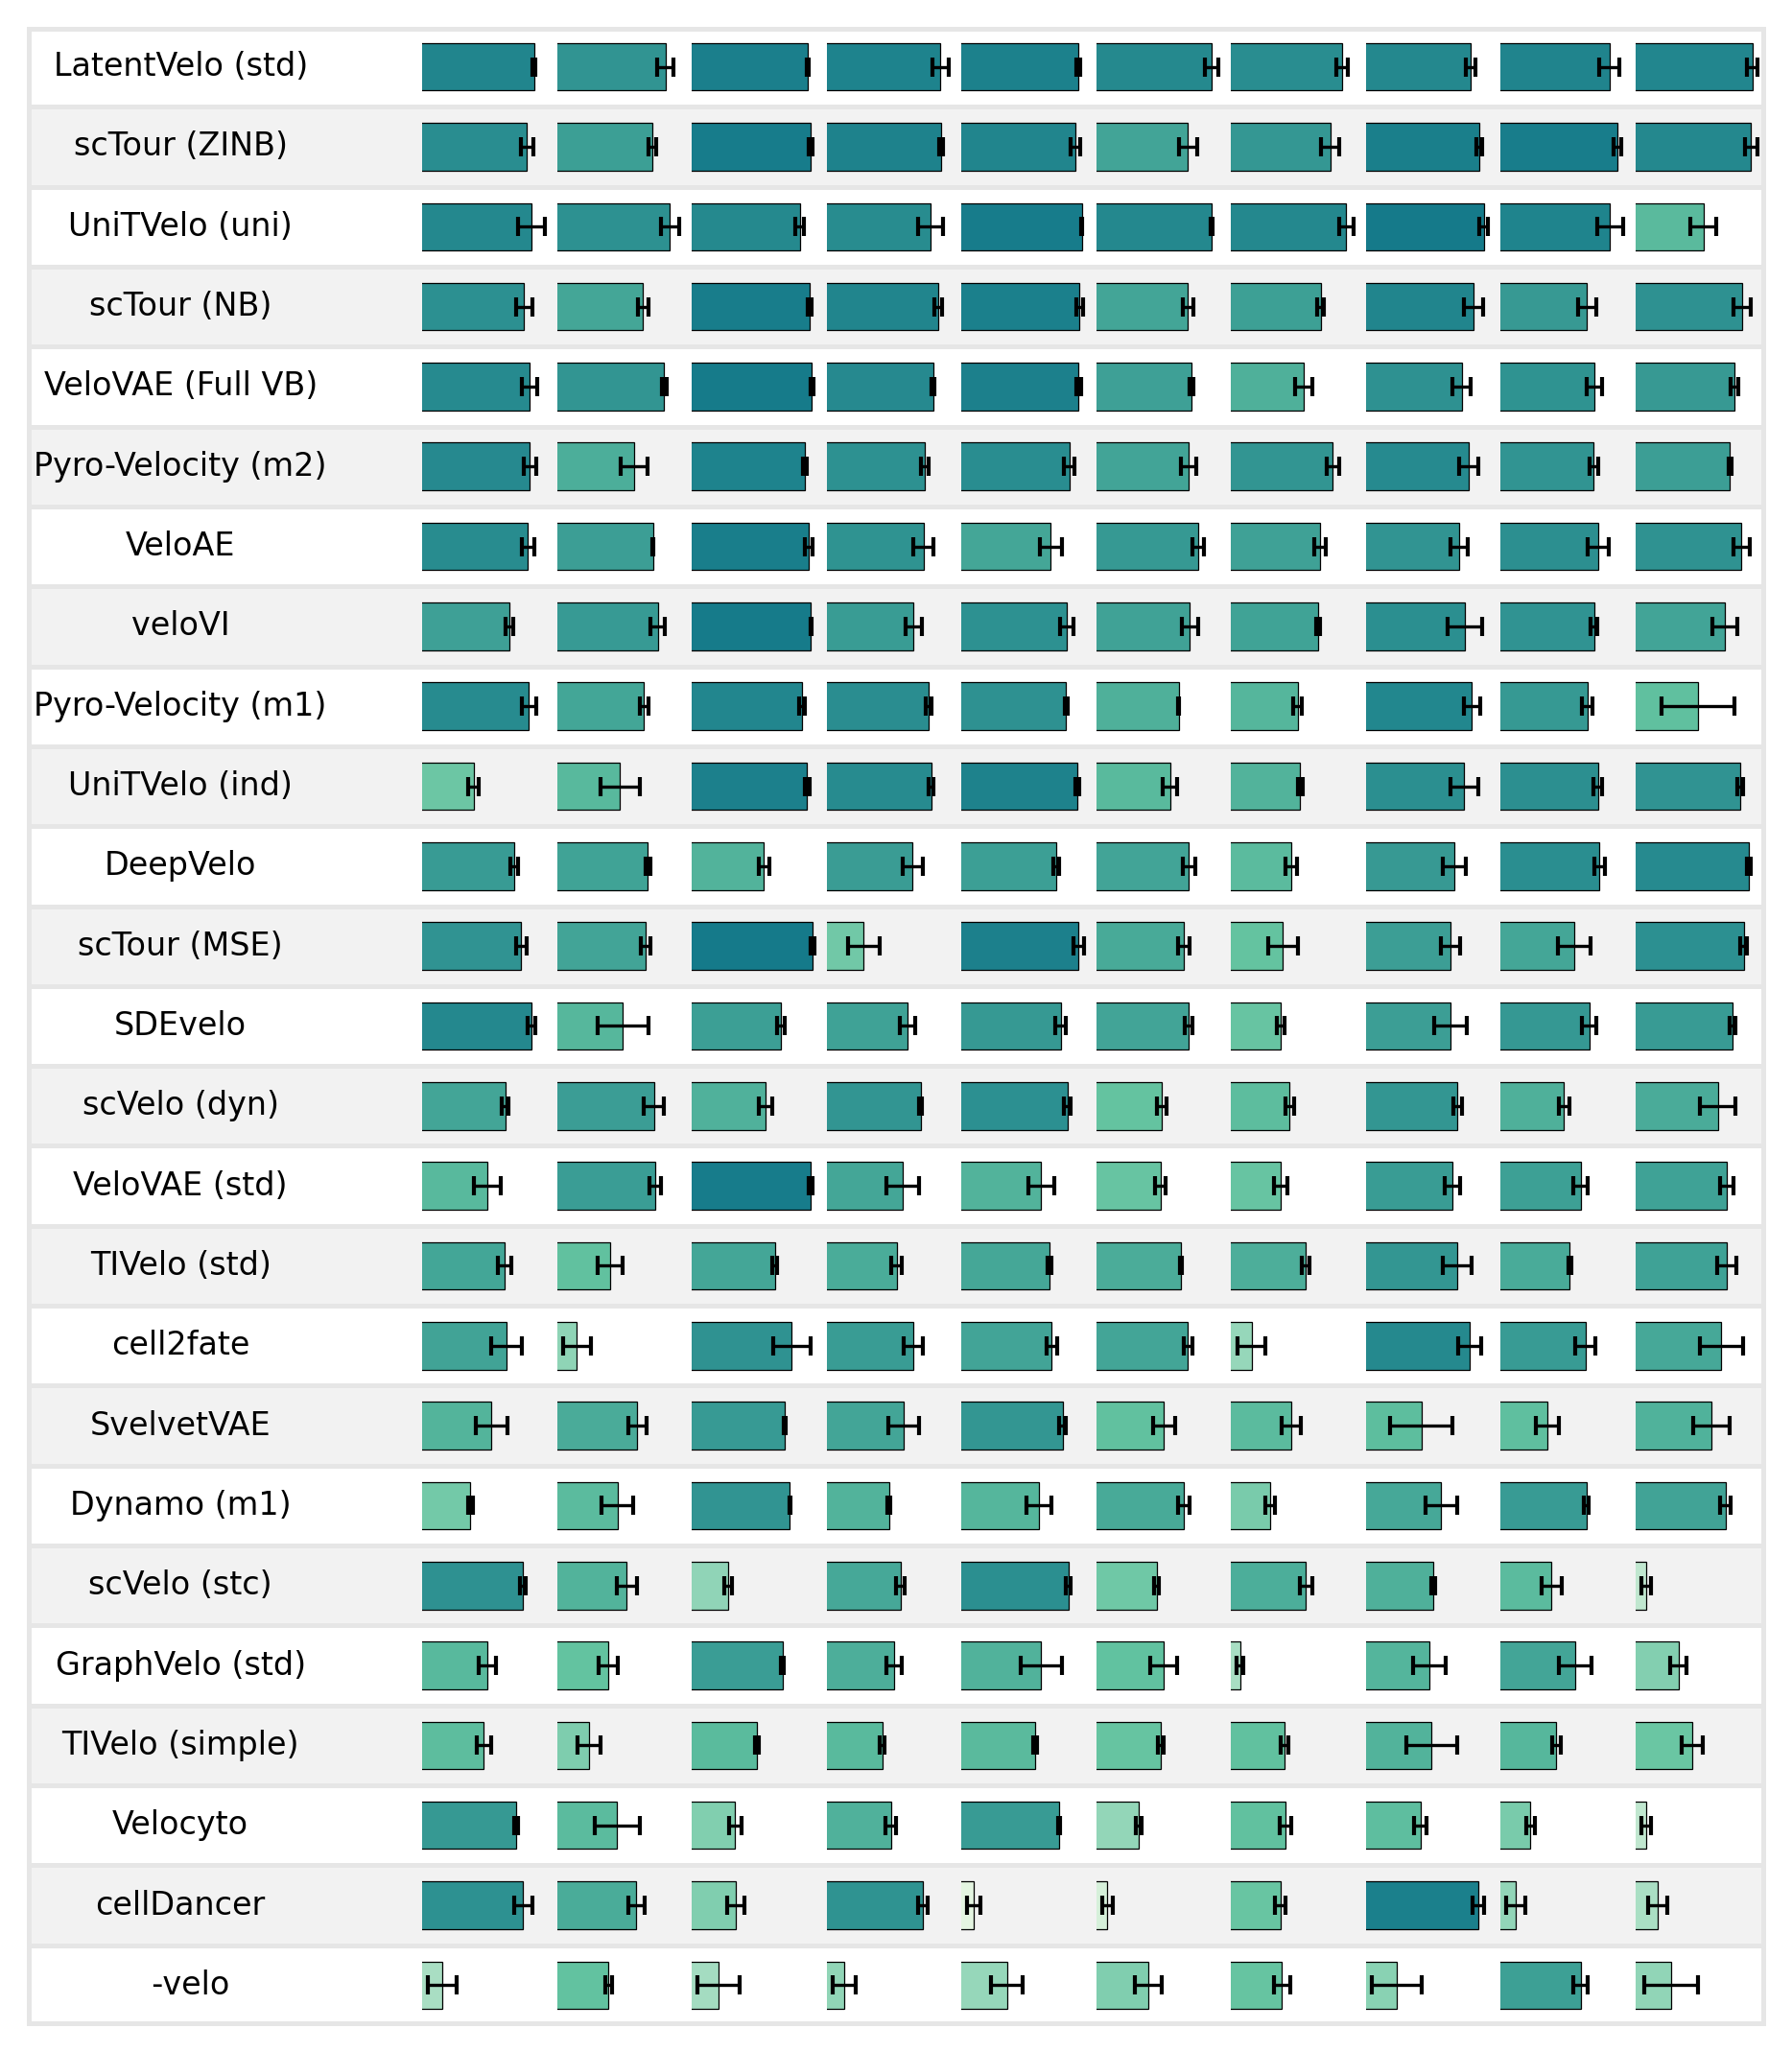

In [32]:
colors = ["#e4f5e1", "#63c3a0", "#157a8a"]
fig, ax = plot_method_dataset_bubble(
    concat_df,
    method_order=method_order,
    dataset_order = ['Data 1', 'Data 2', 'Data 3', 'Data 4', 'Data 5', 'Data 6', 'Data 7', 'Data 8', 'Data 9', 'Data 10'],
    figsize=(7, 9),
    size_transform="sqrt",
    size_clip=(0.05, 0.95),
    size_min=30, size_max=300,
    row_stripes=True,
    stripe_light=1,
    stripe_contrast=0.05,
    column_spacing=1,
    size_domain=(0.0, 0.65),
    colors=colors,
    bar_outline=True,
)
plt.tight_layout()
plt.savefig("icvcoh_barplot.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()

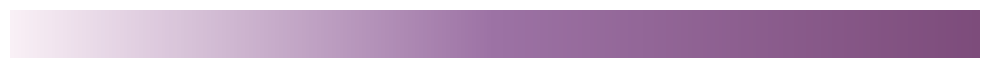

In [33]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

colors = ["#f9f0f6", "#9c72a4", "#7d4c7b"]
# colors = ["#e4f5e1", "#63c3a0", "#157a8a"]
cmap_obj = LinearSegmentedColormap.from_list("custom", colors, N=256)
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
sm.set_array([])
fig, ax = plt.subplots(figsize=(10, 8))
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.5, pad=0.01)
cbar.outline.set_visible(False)
cbar.set_ticks([])
cbar.set_ticklabels([])
ax.remove()
plt.tight_layout()
# plt.savefig("colorbar_cbdir.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()


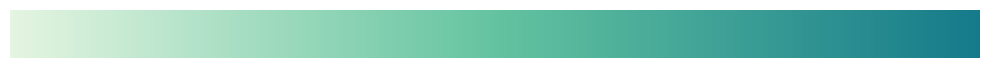

In [34]:
# colors = ["#f9f0f6", "#9c72a4", "#7d4c7b"]
colors = ["#e4f5e1", "#63c3a0", "#157a8a"]
cmap_obj = LinearSegmentedColormap.from_list("custom", colors, N=256)
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
sm.set_array([])
fig, ax = plt.subplots(figsize=(10, 8))
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.5, pad=0.01)
cbar.outline.set_visible(False)
cbar.set_ticks([])
cbar.set_ticklabels([])
ax.remove()
plt.tight_layout()
# plt.savefig("colorbar_icvcoh.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()

## Streamline plot

In [35]:
from pathlib import Path
import os
import scanpy as sc
from scipy.sparse import issparse
import scvelo as scv
dataset = "data01"
methods = ["unitvelo_ind", "veloae","velovi", "unitvelo_uni"]

In [36]:
tsne_colors = [
    "#a8a8ab",  # deep blue
    "#a8a8ab",  # deep red
    "#5b7e91",  # rich green
    "#a0d8ef",  # muted purple
    "#006e54",  # brown
    "#e6b422",  # rose
    "#a8a8ab",  # medium gray
    "#a8a8ab",  # olive yellow
    "#a8a8ab",  # teal
    "#a8a8ab",   # orange
]

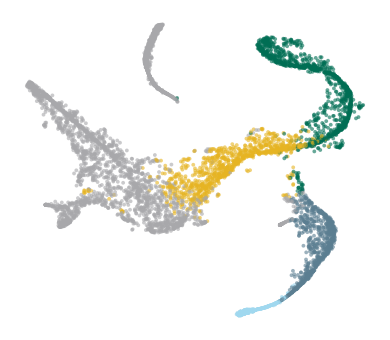

In [37]:
cluster_key = 'clusters'
for method in [methods[0]]:
    adata = sc.read_h5ad(Path(dataset) / f"adata_preprocessed_full.h5ad")
    adata.uns[f'{cluster_key}_colors'] = tsne_colors
    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories
    cell_types = adata.obs[cluster_key].values
    unique_types = np.unique(cell_types)
    color_map = {ct: tsne_colors[i % len(tsne_colors)] for i, ct in enumerate(unique_types)}
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]
    fig, ax = plt.subplots(figsize=(4, 3.5))
    sc.pl.tsne(
        adata,
        color=cluster_key,
        palette=color_map,
        alpha = 0.6,
        title='',
        legend_loc='none',
        ax=ax,
        size=30,
        show=False,
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{dataset}_embedding.png", bbox_inches="tight", dpi=300)
    plt.show()

computing velocity graph (using 20/24 cores)


  0%|          | 0/5780 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'unitvelo_ind_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'unitvelo_ind_velocity_tsne', embedded velocity vectors (adata.obsm)


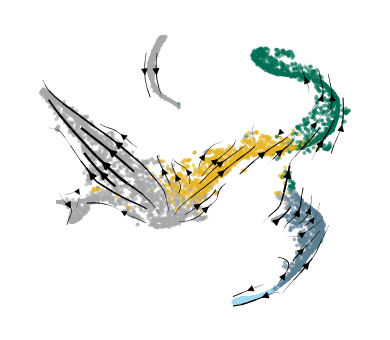

computing velocity graph (using 20/24 cores)


  0%|          | 0/5780 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'veloae_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'veloae_velocity_tsne', embedded velocity vectors (adata.obsm)


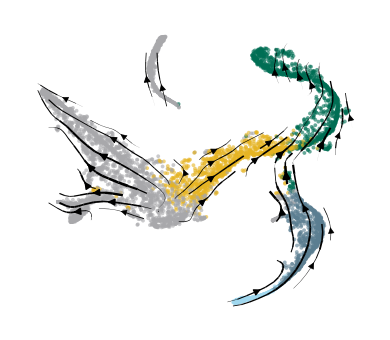

computing velocity graph (using 20/24 cores)


  0%|          | 0/5780 [00:00<?, ?cells/s]

    finished (0:00:06) --> added 
    'velovi_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velovi_velocity_tsne', embedded velocity vectors (adata.obsm)


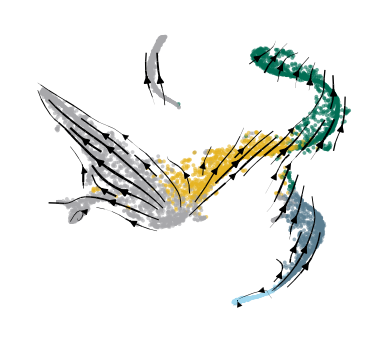

computing velocity graph (using 20/24 cores)


  0%|          | 0/5780 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'unitvelo_uni_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'unitvelo_uni_velocity_tsne', embedded velocity vectors (adata.obsm)


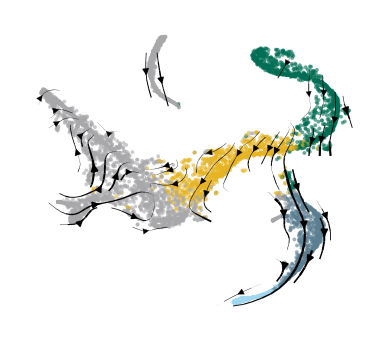

In [38]:
cluster_key = 'clusters'
old_adata = sc.read_h5ad(Path(dataset) / f"adata_preprocessed_full.h5ad")
for method in methods:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad(Path(dataset) / f"adata_run_{method}_full.h5ad")
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])
    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True
    
    if method == 'veloae':
        tsne_old = old_adata.obsm["X_tsne"]
        cells = adata.obs_names
        tsne_new = tsne_old[old_adata.obs_names.get_indexer(cells), :]
        adata.obsm["X_tsne"] = tsne_new

    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform,n_jobs=20)

    adata.uns[f'{cluster_key}_colors'] = tsne_colors
    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories
    cell_types = adata.obs[cluster_key].values
    unique_types = np.unique(cell_types)
    color_map = {ct: tsne_colors[i % len(tsne_colors)] for i, ct in enumerate(unique_types)}
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]
    kwargs = dict(
        frameon=True, add_margin=.1,density=1,linewidth=1,
        size=30,alpha = 0.6,
    )

    # atac size = 120

    fig, ax = plt.subplots(figsize=(4, 3.5))
    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='tsne',
        title='',
        # legend_loc = 'upper right',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{method}_{dataset}_stream..png", bbox_inches="tight", dpi=300)
    plt.show()

In [39]:
from pathlib import Path
import os
import scanpy as sc
from scipy.sparse import issparse
import scvelo as scv
dataset = "data03"
methods = ["unitvelo_ind", "veloae","velovi", "unitvelo_uni"]

In [40]:
umap_colors = [
    "#c8b0b7", "#b88e8d", "#8e7caf", "#7973c0", "#4c5698"
]

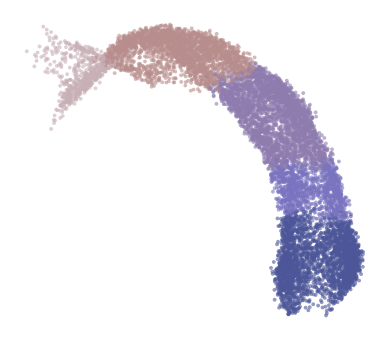

In [41]:
cluster_key = 'celltype'
old_adata = sc.read_h5ad(Path(dataset) / "gastrulation_erythroid.h5ad")
for method in [methods[0]]:
    adata = sc.read_h5ad(Path(dataset) / f"adata_preprocessed_full.h5ad")
    adata.uns[f'{cluster_key}_colors'] = umap_colors
    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories
    cell_types = adata.obs[cluster_key].values
    unique_types = np.unique(cell_types)
    color_map = {ct: umap_colors[i % len(umap_colors)] for i, ct in enumerate(unique_types)}
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]
    fig, ax = plt.subplots(figsize=(4, 3.5))

    umap_old = old_adata.obsm["X_umap"]
    cells = adata.obs_names
    umap_new = umap_old[old_adata.obs_names.get_indexer(cells), :]
    adata.obsm["X_umap"] = umap_new

    sc.pl.umap(
        adata,
        color=cluster_key,
        palette=color_map,
        alpha = 0.6,
        title='',
        legend_loc='none',
        ax=ax,
        size=30,
        show=False,
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{dataset}_embedding.png", bbox_inches="tight", dpi=300)
    plt.show()

computing velocity graph (using 20/24 cores)


  0%|          | 0/9815 [00:00<?, ?cells/s]

    finished (0:00:18) --> added 
    'unitvelo_ind_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'unitvelo_ind_velocity_umap', embedded velocity vectors (adata.obsm)


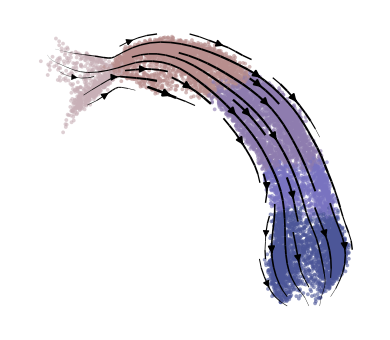

computing velocity graph (using 20/24 cores)


  0%|          | 0/9815 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'veloae_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'veloae_velocity_umap', embedded velocity vectors (adata.obsm)


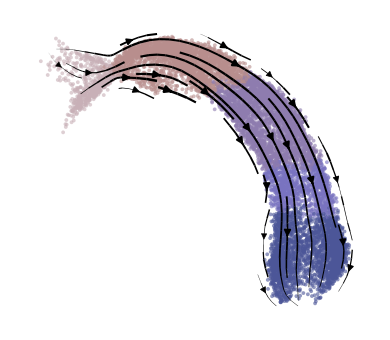

computing velocity graph (using 20/24 cores)


  0%|          | 0/9815 [00:00<?, ?cells/s]

    finished (0:00:15) --> added 
    'velovi_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velovi_velocity_umap', embedded velocity vectors (adata.obsm)


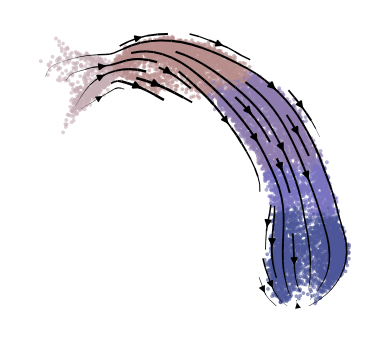

computing velocity graph (using 20/24 cores)


  0%|          | 0/9815 [00:00<?, ?cells/s]

    finished (0:00:14) --> added 
    'unitvelo_uni_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'unitvelo_uni_velocity_umap', embedded velocity vectors (adata.obsm)


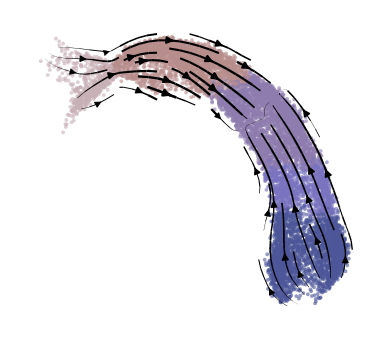

In [42]:
cluster_key = 'celltype'
old_adata = sc.read_h5ad( Path(dataset) / "gastrulation_erythroid.h5ad")
for method in methods:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad(Path(dataset) / f"adata_run_{method}_full.h5ad")
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])
    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True
    
    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform,n_jobs=20)

    adata.uns[f'{cluster_key}_colors'] = umap_colors
    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories
    cell_types = adata.obs[cluster_key].values
    unique_types = np.unique(cell_types)
    color_map = {ct: umap_colors[i % len(umap_colors)] for i, ct in enumerate(unique_types)}
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]
    kwargs = dict(
        frameon=True, add_margin=.1,density=1,linewidth=1,
        size=30,alpha = 0.6,
    )

    # atac size = 120
    umap_old = old_adata.obsm["X_umap"]
    cells = adata.obs_names
    umap_new = umap_old[old_adata.obs_names.get_indexer(cells), :]
    adata.obsm["X_umap"] = umap_new

    fig, ax = plt.subplots(figsize=(4, 3.5))
    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='umap',
        title='',
        # legend_loc = 'upper right',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{method}_{dataset}_stream.png", bbox_inches="tight", dpi=300)
    plt.show()

In [43]:
from pathlib import Path
import os
import scanpy as sc
from scipy.sparse import issparse
import scvelo as scv
methods = ["velocyto","scvelo_stc"]

In [44]:
# methods = ["velocyto","scvelo_st"]
# dataset = "data07" #umap,celltype
# cluster_key = 'clusters'
# output_dir = './data07'
# os.makedirs(output_dir, exist_ok=True)

# for k in range(1):
#     for method in methods:
#         input_path = f'{output_dir}/adata_run_{method}_full.h5ad'
#         if not os.path.exists(input_path):
#             print(f"Skipping {input_path}, file not found.")
#             continue
            
#         adata = sc.read(input_path)

#         cluster_to_celltype = {
#             "c0": "GluN",
#             "c1": "CGE IN",
#             "c2": "GluN",
#             "c3": "MGE IN",
#             "c4": "GluN",
#             "c5": "GluN",
#             "c6": "Early RG",
#             "c7": "GluN",
#             "c8": "Cyc. Prog.",
#             "c9": "GluN",
#             "c10": "Late RG",
#             "c11": "mGPC",
#             "c12": "GluN",
#             "c13": "SP",
#             "c14": "nIPC",
#             "c15": "GluN",
#             "c16": "MG",
#             "c17": "OPC/Oligo",
#             "c18": "tRG",
#             "c19": "Peric.",
#             "c20": "EC",
#             "c21": "RBC",
#             "c22": "VLMC"
#         }
#         adata.obs[cluster_key] = adata.obs['seurat_clusters'].map(cluster_to_celltype)

#         if cluster_key in adata.obs:
#             adata.obs = adata.obs[[cluster_key]]
            
#         else:
#             print(f"Warning: {cluster_key} not found in {method}_{k}, keeping empty obs.")
#             adata.obs = pd.DataFrame(index=adata.obs.index)

#         # adata.var = pd.DataFrame(index=adata.var.index)

#         adata.uns = {'neighbors': adata.uns['neighbors']} if 'neighbors' in adata.uns else {}
        
#         adata.varm = {} 

#         target_layers = ['Ms','Mu', 'spliced','unspliced']
        
#         if method == 'graphvelo':
#             if 'graphvelo_velocity' in adata.layers:
#                 adata.layers['graphvelo_std_velocity'] = adata.layers.pop('graphvelo_velocity')
#                 target_layers.append('graphvelo_std_velocity')
#                 method = 'graphvelo_std'
#         elif method == 'latentvelo':
#             if 'latentvelo_rna_velocity' in adata.layers:
#                 adata.layers['latentvelo_std_velocity'] = adata.layers.pop('latentvelo_rna_velocity')
#                 target_layers.append('latentvelo_std_velocity')
#                 method = 'latentvelo_std'
#         elif method == 'scvelo_dy':
#             if 'scvelo_dy_velocity' in adata.layers:
#                 adata.layers['scvelo_dyn_velocity'] = adata.layers.pop('scvelo_dy_velocity')
#                 target_layers.append('scvelo_dyn_velocity')
#                 method = 'scvelo_dyn'
#         elif method == 'scvelo_st':
#             if 'scvelo_st_velocity' in adata.layers:
#                 adata.layers['scvelo_stc_velocity'] = adata.layers.pop('scvelo_st_velocity')
#                 target_layers.append('scvelo_stc_velocity')
#                 method = 'scvelo_stc'
        
#         else:
#             target_layers.append(f'{method}_velocity')


#         for key in list(adata.layers.keys()):
#             if key not in target_layers:
#                 del adata.layers[key]
        
#         import mygene

#         adata.var["gene_id"] = adata.var_names.astype(str)
#         adata.var["gene_id_clean"] = adata.var["gene_id"].str.replace(r"\.\d+$", "", regex=True)

#         mg = mygene.MyGeneInfo()

#         res = mg.querymany(
#             adata.var["gene_id_clean"].tolist(),
#             scopes="ensembl.gene",
#             fields="symbol",
#             species="human",
#             as_dataframe=True
#         )

#         res = res[~res.index.duplicated(keep="first")]
#         id_to_symbol = res["symbol"].dropna().to_dict()

#         adata.var["gene_symbol"] = adata.var["gene_id_clean"].map(id_to_symbol)

#         adata.var_names = adata.var["gene_symbol"].fillna(adata.var["gene_id"]).astype(str)
#         adata.var_names_make_unique()
#         adata.var.index.name = None
#         save_path = f'{output_dir}/adata_run_{method}_full_new.h5ad'
#         adata.write(save_path, compression='gzip')
#         print(f"Saved: {save_path}")

computing velocity graph (using 20/24 cores)


  0%|          | 0/54542 [00:00<?, ?cells/s]

    finished (0:00:50) --> added 
    'velocyto_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:05) --> added
    'velocyto_velocity_umap', embedded velocity vectors (adata.obsm)


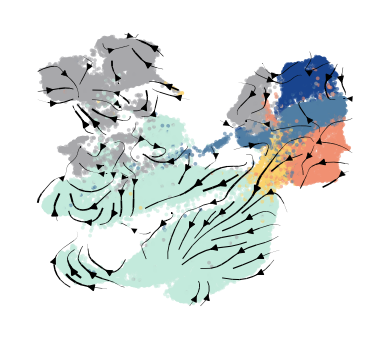

computing velocity graph (using 20/24 cores)


  0%|          | 0/54542 [00:00<?, ?cells/s]

    finished (0:01:58) --> added 
    'scvelo_stc_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:05) --> added
    'scvelo_stc_velocity_umap', embedded velocity vectors (adata.obsm)


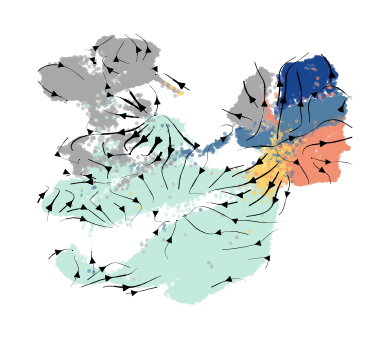

In [45]:
cluster_key = 'clusters'
dataset = 'data07'

for method in ['velocyto', 'scvelo_stc']:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad( Path(dataset) / f"adata_run_{method}_full_new.h5ad")

    all_types = adata.obs[cluster_key].unique()

    color_map = {
        'Cyc. Prog.': "#f19072",
        'Early RG': "#507ea4",
        'Late RG': "#19448e",
        'nIPC': "#fbd26b",
        'GluN': "#c3eadc",
    }

    # 给未指定的类别统一赋值
    for ct in all_types:
        if ct not in color_map:
            color_map[ct] = "#a8a8ab"

    adata.layers[vkey] = adata.layers[vkey].astype(np.float32)
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])

    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True

    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform, n_jobs=20)

    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories

    # 按 category 顺序生成颜色列表
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]

    kwargs = dict(
        frameon=True, add_margin=.1, density=1, linewidth=1,
        size=30, alpha=0.6,
    )

    fig, ax = plt.subplots(figsize=(4, 3.5))

    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='umap',
        title='',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{dataset}_{method}_stream.png", bbox_inches="tight", dpi=300)
    plt.show()

In [46]:
# methods = ["velocyto","scvelo_stc"]
# dataset = "data08" #umap,celltype
# cluster_key = 'clusters'
# output_dir = './data08'
# os.makedirs(output_dir, exist_ok=True)

# for k in range(1):
#     for method in methods:
#         input_path = f'{output_dir}/adata_run_{method}_full.h5ad'
#         if not os.path.exists(input_path):
#             print(f"Skipping {input_path}, file not found.")
#             continue
            
#         adata = sc.read(input_path)

#         if cluster_key in adata.obs:
#             adata.obs = adata.obs[[cluster_key]]
            
#         else:
#             print(f"Warning: {cluster_key} not found in {method}_{k}, keeping empty obs.")
#             adata.obs = pd.DataFrame(index=adata.obs.index)

#         # adata.var = pd.DataFrame(index=adata.var.index)

#         adata.uns = {'neighbors': adata.uns['neighbors']} if 'neighbors' in adata.uns else {}
        
#         adata.varm = {} 

#         target_layers = ['Ms','Mu', 'spliced','unspliced']
        
#         if method == 'graphvelo':
#             if 'graphvelo_velocity' in adata.layers:
#                 adata.layers['graphvelo_std_velocity'] = adata.layers.pop('graphvelo_velocity')
#                 target_layers.append('graphvelo_std_velocity')
#                 method = 'graphvelo_std'
#         elif method == 'latentvelo':
#             if 'latentvelo_rna_velocity' in adata.layers:
#                 adata.layers['latentvelo_std_velocity'] = adata.layers.pop('latentvelo_rna_velocity')
#                 target_layers.append('latentvelo_std_velocity')
#                 method = 'latentvelo_std'
#         elif method == 'scvelo_dy':
#             if 'scvelo_dy_velocity' in adata.layers:
#                 adata.layers['scvelo_dyn_velocity'] = adata.layers.pop('scvelo_dy_velocity')
#                 target_layers.append('scvelo_dyn_velocity')
#                 method = 'scvelo_dyn'
        
#         else:
#             target_layers.append(f'{method}_velocity')


#         for key in list(adata.layers.keys()):
#             if key not in target_layers:
#                 del adata.layers[key]
        
#         save_path = f'{output_dir}/adata_run_{method}_full_new.h5ad'
#         adata.write(save_path, compression='gzip')
#         print(f"Saved: {save_path}")

computing velocity graph (using 20/24 cores)


  0%|          | 0/9443 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'velocyto_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocyto_velocity_umap', embedded velocity vectors (adata.obsm)


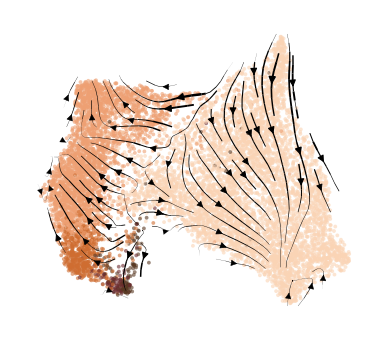

computing velocity graph (using 20/24 cores)


  0%|          | 0/9443 [00:00<?, ?cells/s]

    finished (0:00:05) --> added 
    'scvelo_stc_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'scvelo_stc_velocity_umap', embedded velocity vectors (adata.obsm)


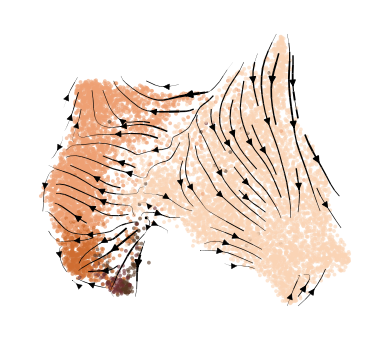

In [47]:
cluster_key = 'clusters'
dataset = 'data08'

for method in ['velocyto', 'scvelo_stc']:
    vkey = f"{method}_velocity"

    adata = sc.read_h5ad( Path(dataset) / f"adata_run_{method}_full_new.h5ad")

    all_types = adata.obs[cluster_key].unique()

    color_map = {
        'Mature \n Excitatory Neuron': "#fad4b5",
        'Immature \n Excitatory Neuron': "#eea073",
        'Newborn \n Excitatory Neuron': "#cf6d31",
        'Intermediate \n Progenitor': "#6c2c2f",
        'Radial Glia': "#583822",
    }

    adata.layers[vkey] = adata.layers[vkey].astype(np.float32)
    if issparse(adata.layers[vkey]):
        adata.layers[vkey] = adata.layers[vkey].toarray().astype(np.float32)
    adata.layers[vkey] = np.where(np.isnan(adata.layers[vkey]), 0, adata.layers[vkey])

    sqrt_transform = False
    if method in ["unitvelo_ind", "unitvelo_uni"]:
        sqrt_transform = True

    scv.tl.velocity_graph(adata, vkey=vkey, sqrt_transform=sqrt_transform, n_jobs=20)

    adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
    cluster_order = adata.obs[cluster_key].cat.categories

    # 按 category 顺序生成颜色列表
    adata.uns[f'{cluster_key}_colors'] = [color_map[c] for c in cluster_order]

    kwargs = dict(
        frameon=True, add_margin=.1, density=1, linewidth=1,
        size=30, alpha=0.6,
    )

    fig, ax = plt.subplots(figsize=(4, 3.5))

    scv.pl.velocity_embedding_stream(
        adata,
        color=cluster_key,
        vkey=vkey,
        basis='umap',
        title='',
        legend_loc='none',
        ax=ax,
        **kwargs,
        show=False
    )
    ax.set_title('')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{dataset}_{method}_stream.png", bbox_inches="tight", dpi=300)
    plt.show()